In [5]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
from sklearn.model_selection import train_test_split
import os, sys
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# add the project root to sys.path
root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root not in sys.path:
    sys.path.insert(0, root)

print(root)

from src.frengression import Frengression
# from utils_train import preprocess, TabularDataset
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.pyplot as plt
import seaborn as sns

/home/ruyan/Documents/frengression_pkg


In [11]:
import pandas as pd

# Load the data from the CSV file
data_path = os.path.join(root, 'data/frugal_data_catXA.csv')
data = pd.read_csv(data_path)

# Convert X4 and X5 to categorical columns
data['X4'] = data['X4'].astype('int')
data['X5'] = data['X5'].astype('int')
print(data.head())

# One-hot encode column 'X6' and 'A'
data = pd.get_dummies(data, columns=['X6'], prefix='X6')
data = pd.get_dummies(data, columns=['A'], prefix='A')

# Reorder the columns to have categorical X first, followed by continuous X, then A, then Y
data = data[['X4', 'X5', 'X6_1', 'X6_2', 'X6_3', 'X1', 'X2', 'X3', 'A_1', 'A_2', 'A_3', 'Y']]
data.head()

         X1        X2        X3  X4  X5  X6  A         Y
0 -1.284136  1.008260  1.536425   0   0   3  3 -4.073708
1  0.172495  1.455019  0.752191   0   0   3  1 -0.336862
2  0.992804  1.513960  1.513365   1   0   1  1  0.153847
3 -0.176049  0.972939  2.403191   1   0   1  1  0.326904
4  0.907444  0.779792  1.431335   1   0   1  1  0.063916


,X4,X5,X6_1,X6_2,X6_3,X1,X2,X3,A_1,A_2,A_3,Y
0,0,0,False,False,True,-1.284136,1.008260,1.536425,False,False,True,-4.073708
1,0,0,False,False,True,0.172495,1.455019,0.752191,True,False,False,-0.336862
2,1,0,True,False,False,0.992804,1.513960,1.513365,True,False,False,0.153847
3,1,0,True,False,False,-0.176049,0.972939,2.403191,True,False,False,0.326904
4,1,0,True,False,False,0.907444,0.779792,1.431335,True,False,False,0.063916


In [12]:
p = 8 # dimension of covariates 
cat_intervention = True
# Split the data into training, validation, and test sets
df_tr, df_temp = train_test_split(data, test_size=0.4, random_state=42)
df_val, df_te = train_test_split(df_temp, test_size=0.5, random_state=42)

z_tr = torch.tensor(df_tr[[col for col in df_tr.columns if col.startswith('X')]].astype(float).values,dtype=torch.float32)
x_tr = torch.tensor(df_tr[[col for col in df_tr.columns if col.startswith('A')]].values, dtype=torch.float32) if cat_intervention else \
            torch.tensor(df_tr['A'].values, dtype=torch.float32).view(-1, 1)
y_tr = torch.tensor(df_tr['Y'].values, dtype=torch.float32).view(-1, 1)
   
z_te_np = df_te[[col for col in df_te.columns if col.startswith('X')]].values
x_te_np = df_te[[col for col in df_te.columns if col.startswith('A')]].values
y_te_np = df_te['Y'].values
z_te_np = torch.tensor(z_te_np.astype(float))

print(f"Training set size: {len(df_tr)}")
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_te)}")

Training set size: 6000
Validation set size: 2000
Test set size: 2000


In [13]:
model0 = Frengression(x_dim = x_tr.shape[1], y_dim = y_tr.shape[1], z_dim =z_tr.shape[1], 
                             noise_dim=1, num_layer=2, hidden_dim=800, y_cat=False,z_cat_dims=[2,2,3],
                             device=device, x_cat=cat_intervention
                            )

In [14]:
# Train Frengression model y part
num_iters = 10000

model0.train_y(x=x_tr,
                       z=z_tr, 
                       y=y_tr,
                       num_iters=num_iters, lr=5e-4, print_every_iter=1000, tol=0)



Epoch 1: loss 2.6256,	loss_y 1.9240, 1.9900, 0.1319,	loss_eta 0.7016, 0.8016, 0.2000
Epoch 1000: loss 0.8744,	loss_y 0.3137, 0.6374, 0.6474,	loss_eta 0.5607, 1.1225, 1.1236
Epoch 2000: loss 0.8569,	loss_y 0.2913, 0.5887, 0.5948,	loss_eta 0.5656, 1.0947, 1.0582
Epoch 3000: loss 0.8613,	loss_y 0.2870, 0.5888, 0.6036,	loss_eta 0.5743, 1.0922, 1.0359
Epoch 4000: loss 0.8393,	loss_y 0.2712, 0.5555, 0.5687,	loss_eta 0.5681, 1.0636, 0.9910
Epoch 5000: loss 0.8327,	loss_y 0.2583, 0.5266, 0.5366,	loss_eta 0.5745, 1.0683, 0.9877
Epoch 6000: loss 0.8084,	loss_y 0.2521, 0.5204, 0.5365,	loss_eta 0.5562, 1.0494, 0.9864
Epoch 7000: loss 0.8105,	loss_y 0.2463, 0.5197, 0.5467,	loss_eta 0.5642, 1.0536, 0.9787
Epoch 8000: loss 0.8111,	loss_y 0.2381, 0.4959, 0.5156,	loss_eta 0.5730, 1.0545, 0.9632
Epoch 9000: loss 0.7882,	loss_y 0.2261, 0.4781, 0.5041,	loss_eta 0.5621, 1.0301, 0.9361
Epoch 10000: loss 0.8054,	loss_y 0.2329, 0.4839, 0.5020,	loss_eta 0.5724, 1.0412, 0.9374


In [15]:
# Sample interventional distributions 
P0 = model0.sample_causal_margin(torch.tensor([[1,0,0]], dtype=torch.int32).to(device), sample_size=20000).cpu().numpy().reshape(-1,y_tr.shape[1])
P1 = model0.sample_causal_margin(torch.tensor([[0,1,0]], dtype=torch.int32).to(device), sample_size=20000).cpu().numpy().reshape(-1,y_tr.shape[1])#.reshape(-1, 1)
P2 = model0.sample_causal_margin(torch.tensor([[0,0,1]], dtype=torch.int32).to(device), sample_size=20000).cpu().numpy().reshape(-1,y_tr.shape[1])#.reshape(-1, 1)

# Estimate ATE
print(np.mean(P1)-np.mean(P0))# The true ATE between A=2 and A=1 is -2
print(np.mean(P2)-np.mean(P1))# The true ATE between A=3 and A=2 is -0.5
# The model works well on simulated data

-1.9606923
-0.53314805


In [16]:
# Train model xz part (if we need to infer/simulate covariates and treatment variables)
model0.train_xz(x_tr, z_tr,num_iters=6000,lr=1e-4, print_every_iter=1000)


Epoch 1: loss 2.3925, loss1 2.6384, loss2 0.4919
Epoch 1000: loss 1.8108, loss1 3.5753, loss2 3.5290
Epoch 2000: loss 1.8061, loss1 3.5779, loss2 3.5436
Epoch 3000: loss 1.8062, loss1 3.5882, loss2 3.5641
Epoch 4000: loss 1.7860, loss1 3.5594, loss2 3.5468
Epoch 5000: loss 1.7961, loss1 3.5732, loss2 3.5542
Epoch 6000: loss 1.7825, loss1 3.5669, loss2 3.5688


tensor([ 0.7255,  0.3250,  0.4015,  0.2580,  0.3405, -0.0055,  0.0712,  0.0385],
       dtype=torch.float64)
[ 0.7685      0.293       0.409       0.29        0.301      -0.02775515
  0.01182908  0.04898058]


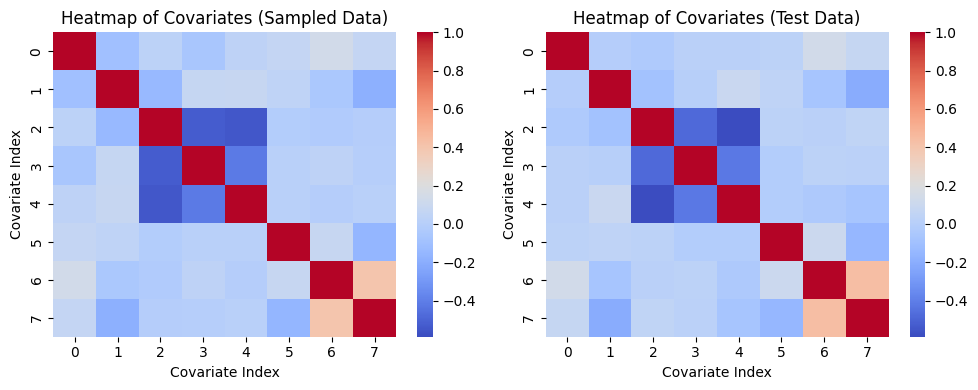

In [17]:
def plot_covariate_heatmaps(z_te_np, z_sample_np):
    """
    Plots heatmaps of covariates for sampled data and test data.

    Parameters:
    - model: The trained model used to sample covariates.
    - z_te_np: Numpy array of covariates from the test dataset.
    - z_sample_np: Numpy array of covariates sampled from the model.
    """
    # Compute the correlation matrix for sampled data
    correlation_matrix = np.corrcoef(z_sample_np, rowvar=False)

    # Compute the true correlation matrix for test data
    true_correlation_matrix = np.corrcoef(z_te_np, rowvar=False)

    # Plot heatmap of covariates
    plt.figure(figsize=(10, 4))

    # Compute the min and max values for the color scale
    vmin = min(correlation_matrix.min(), true_correlation_matrix.min())
    vmax = max(correlation_matrix.max(), true_correlation_matrix.max())

    # Plot the correlation matrix of the sampled data
    plt.subplot(1, 2, 1)
    sns.heatmap(correlation_matrix, cmap="coolwarm", cbar=True, vmin=vmin, vmax=vmax)
    plt.title("Heatmap of Covariates (Sampled Data)")
    plt.xlabel("Covariate Index")
    plt.ylabel("Covariate Index")

    # Compute and plot the true correlation matrix of the test data
    plt.subplot(1, 2, 2)
    sns.heatmap(true_correlation_matrix, cmap="coolwarm", cbar=True, vmin=vmin, vmax=vmax)
    plt.title("Heatmap of Covariates (Test Data)")
    plt.xlabel("Covariate Index")
    plt.ylabel("Covariate Index")

    plt.tight_layout()
    plt.show()

# Example usage:
x_sample0, z_sample0 = model0.sample_xz(sample_size=len(df_te))
        # Convert the tensor to a numpy array if it's not already
z_sample_np0 = z_sample0.cpu().numpy() if isinstance(z_sample0, torch.Tensor) else z_sample0
print(z_te_np.mean(axis=0))
print(z_sample_np0.mean(axis=0))
plot_covariate_heatmaps(z_te_np, z_sample_np0)


In [18]:
# To sample obseravtional data
obs_x, obs_y, obs_z = model0.sample_joint(sample_size=5)
obs_y

tensor([[ 0.8832],
        [-4.6574],
        [-3.5942],
        [-2.8000],
        [-3.0909]], device='cuda:0')